<h1>Bitcoin Predictability: FFT vs Wavelets (Daily Data) or Is it possible to predict next cycles based on Wavelets or FFT</h1>

Predicting financial markets, and especially cryptocurrencies such as Bitcoin, remains a challenging and highly debated problem. Unlike traditional financial assets, Bitcoin exhibits high volatility, non-stationary behavior, and sensitivity to external factors such as market sentiment and macroeconomic events.

In this project, we investigate whether short-term predictability can be extracted from Bitcoin price data using signal processing techniques. Specifically, we explore two approaches:

- Fourier Transform (FFT), which captures global frequency patterns in the data
- Wavelet Transform, which captures localized time-frequency structures

The main goal is to evaluate whether these transformations can produce meaningful features that improve the prediction of future returns. We frame the problem as both a regression task (predicting next return) and a classification task (predicting direction).

This work combines mathematical concepts from signal processing with practical machine learning techniques, aiming to bridge the gap between theoretical analysis and real-world financial applications.

We use daily BTC-USD data from Yahoo Finance via `yfinance`, and keep the modeling lightweight using linear/regularized models from `scikit-learn`.

Our goal is to compare FFT vs Wavelet features in an out-of-sample setting and conclude whether daily BTC moves show meaningful predictability if possible

<hr/>


- We use a **walk-forward style split** (time-series split) to reduce look-ahead bias.


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

# Signal processing
from scipy import fft
from scipy import signal
import pywt

# Modeling
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, roc_auc_score
)

# Plotting
import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(42)

symbol = "BTC-USD"
start = "2014-01-01"

df = yf.download(symbol, start=start, auto_adjust=False, progress=False)
df = df[['Close']].dropna()
df['log_return'] = np.log(df['Close']).diff()
df = df.dropna()

df.head(), df.tail(), df.shape


(Price            Close log_return
 Ticker         BTC-USD           
 Date                             
 2014-09-18  424.440002  -0.074643
 2014-09-19  394.795990  -0.072402
 2014-09-20  408.903992   0.035111
 2014-09-21  398.821014  -0.024968
 2014-09-22  402.152008   0.008317,
 Price              Close log_return
 Ticker           BTC-USD           
 Date                               
 2026-03-12  70493.460938   0.004102
 2026-03-13  70968.265625   0.006713
 2026-03-14  71214.625000   0.003465
 2026-03-15  72789.914062   0.021879
 2026-03-16  74045.765625   0.017106,
 (4198, 2))

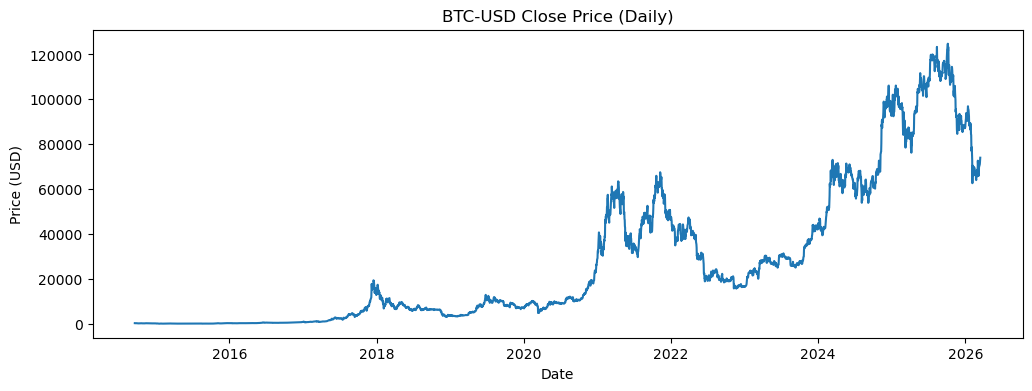

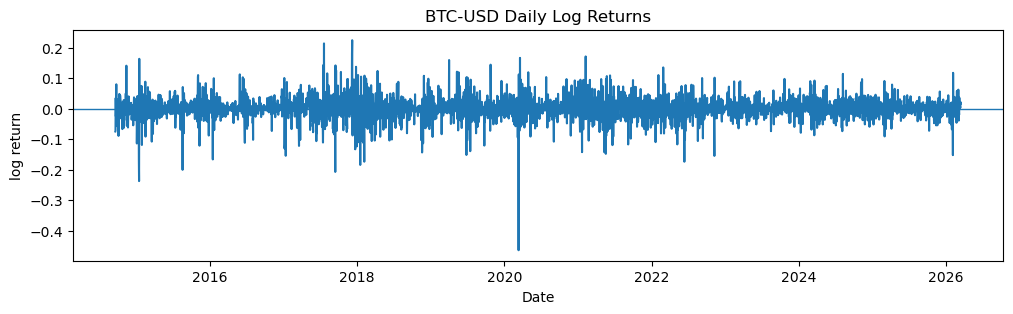

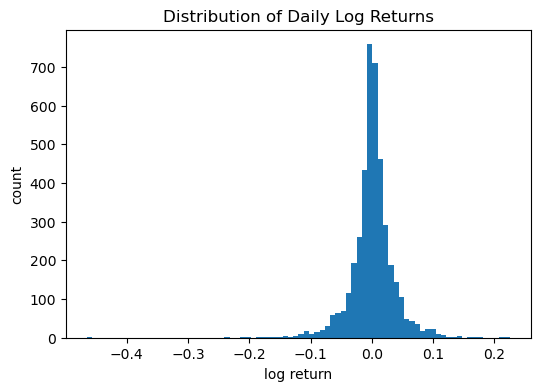

In [ ]:
# Quick sanity plots: price and daily log returns
fig = plt.figure(figsize=(12,4))
plt.plot(df.index, df['Close'])
plt.title("BTC-USD Close Price (Daily)")
plt.xlabel("Date"); plt.ylabel("Price (USD)")
plt.show()

fig = plt.figure(figsize=(12,3))
plt.plot(df.index, df['log_return'])
plt.title("BTC-USD Daily Log Returns")
plt.xlabel("Date"); plt.ylabel("log return")
plt.axhline(0, linewidth=1)
plt.show()

fig = plt.figure(figsize=(6,4))
plt.hist(df['log_return'], bins=80)
plt.title("Distribution of Daily Log Returns")
plt.xlabel("log return"); plt.ylabel("count")
plt.show()

## 2) Problem setup

### Fourier Spectrum

The Fourier spectrum represents the decomposition of a signal into its constituent frequencies. Each component corresponds to a sinusoidal wave with a specific frequency and amplitude. In financial time series, the spectrum can reveal dominant cycles or periodicities that may not be visible in the time domain.

However, the Fourier Transform assumes that the signal is stationary, meaning that its statistical properties do not change over time — an assumption that is often violated in financial data.

---

### Time-Frequency Tradeoff

A fundamental limitation in signal processing is the time-frequency tradeoff. High frequency resolution implies poor time localization, and vice versa.

- Fourier Transform provides excellent frequency resolution but no information about when those frequencies occur.
- Time-domain methods provide exact timing but no frequency decomposition.

This tradeoff is particularly important in financial markets, where patterns and cycles may appear and disappear over time.

---

### Wavelet Scaling

Wavelet transforms address the limitations of Fourier analysis by using localized basis functions that can be scaled and shifted.

- Scaling controls the frequency (large scale → low frequency, small scale → high frequency)
- Shifting controls the position in time

This allows wavelets to capture both short-term fluctuations and long-term trends simultaneously, making them well-suited for non-stationary signals like financial time series.



We build features from a rolling window of past returns

$$
\{r_{t-W+1}, \dots, r_t\}
$$

and predict

$$
r_{t+1}.
$$

Let $$(\mathbf{x}_t)$$ be features computed at time \(t\), using only information available up to \(t\).

**Why features?**  
Raw returns are noisy; FFT and Wavelets summarize frequency/time-scale structure in the recent window.

We'll compare:

- **FFT features:** magnitude spectrum of the rolling window
- **Wavelet features:** average absolute CWT coefficients across a set of scales

We also include a simple baseline: predict 0 return (regression) / predict majority class (classification).




In [ ]:
W = 128   # rolling window length in days
K = 16    # number of FFT magnitudes to keep (low frequencies)
SCALES = np.array([2, 4, 8, 16, 32, 64])  # wavelet scales for CWT

returns = df['log_return'].values
dates = df.index

len(returns), W

(4198, 128)

<h2>3) Feature engineering</h2>

<h3>3.1 FFT features</h3>

For a window $$\mathbf{r} = [r_{t-W+1},\dots,r_t]$$, the discrete Fourier transform (DFT) is:

$$
X_k = \sum_{n=0}^{W-1} r_{t-W+1+n} \, e^{-j 2\pi kn/W}
$$

We use the **real FFT** (`scipy.fft.rfft`) and keep the **magnitude** of the first \(K\) non-DC components:
$$
\text{FFTfeat}_k = |X_k|, \quad k=1,2,\dots,K
$$

(DC component \(k=0\) mostly reflects the mean, which is ~0 for returns.)


<h3>3.2 Wavelet features (CWT)</h3>

Wavelets capture localized, multi-scale behavior. The continuous wavelet transform (CWT) is:

$$
W(a,b) = \int_{-\infty}^{\infty} x(t)\,\frac{1}{\sqrt{|a|}}\,\psi^*\left(\frac{t-b}{a}\right) dt
$$

where \(a\) is the **scale** and \(b\) is the **time shift**.

Using SciPy's `signal.cwt` with a Morlet wavelet (`signal.morlet2`), we compute coefficients for several scales and summarize each scale by the **mean absolute coefficient** in the window:

$$
\text{WAVfeat}(a) = \frac{1}{W}\sum_{b} |W(a,b)|
$$


In [ ]:
def fft_features(x_window: np.ndarray, k: int = 16) -> np.ndarray:
    """FFT magnitude features from a return window."""
    x = x_window - np.mean(x_window)  # remove mean (helps reduce DC)
    X = fft.rfft(x)
    mag = np.abs(X)
    # skip DC at index 0, take next k components (pad if needed)
    feats = mag[1:1+k]
    if len(feats) < k:
        feats = np.pad(feats, (0, k-len(feats)))
    return feats

def wavelet_features(x_window: np.ndarray, scales: np.ndarray) -> np.ndarray:
    """CWT (Morlet) features summarized by mean absolute coefficient per scale."""
    x = x_window - np.mean(x_window)
    # Use PyWavelets instead of deprecated scipy.signal.cwt
    cwtm, freqs = pywt.cwt(x, scales, 'morl')  # 'morl' = Morlet wavelet
    feats = np.mean(np.abs(cwtm), axis=1)
    return feats


# Build dataset
X_fft = []
X_wav = []
y_reg = []
y_cls = []
idx = []

for t in range(W-1, len(returns)-1):
    window = returns[t-W+1:t+1]

    X_fft.append(fft_features(window, K))
    X_wav.append(wavelet_features(window, SCALES))

    y_next = returns[t+1]
    y_reg.append(y_next)
    y_cls.append(1 if y_next > 0 else 0)
    idx.append(dates[t])

# Build dataset
X_fft = []
X_wav = []
y_reg = []
y_cls = []
idx = []

for t in range(W-1, len(returns)-1):
    window = returns[t-W+1:t+1]
    X_fft.append(fft_features(window, K))
    X_wav.append(wavelet_features(window, SCALES))
    y_next = returns[t+1]
    y_reg.append(y_next)
    y_cls.append(1 if y_next > 0 else 0)
    idx.append(dates[t])

X_fft = np.asarray(X_fft)
X_wav = np.asarray(X_wav)
y_reg = np.asarray(y_reg)
y_cls = np.asarray(y_cls)
idx = pd.DatetimeIndex(idx)

X_fft.shape, X_wav.shape, y_reg.shape


((4070, 16), (4070, 6), (4070,))

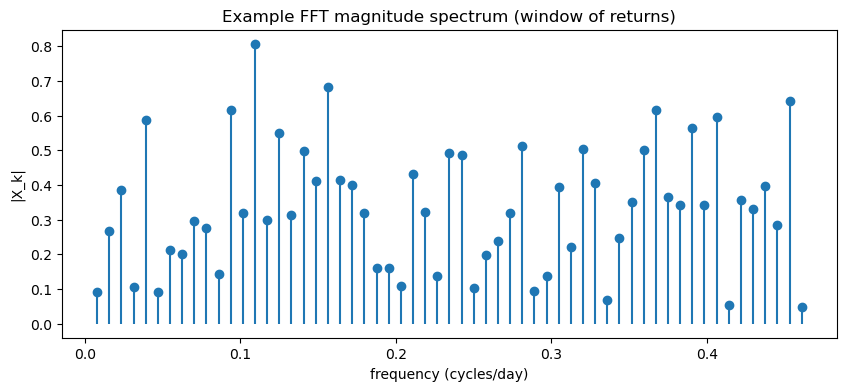

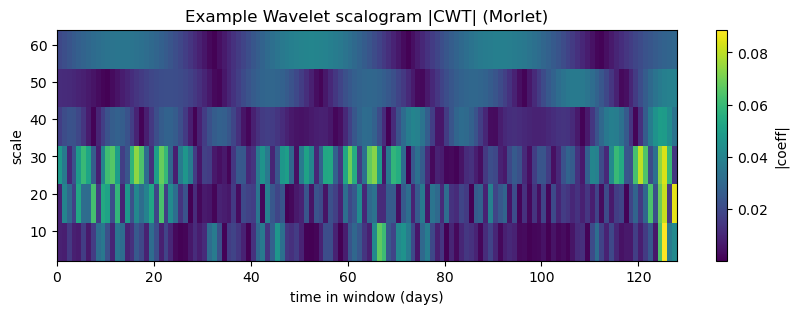

In [ ]:
# Visual example: FFT spectrum and Wavelet scalogram for one window
example_i = int(len(y_reg)*0.7)
window = returns[example_i:example_i+W]

# FFT
X = fft.rfft(window - window.mean())
freqs = fft.rfftfreq(W, d=1.0)  # cycles/day (since d=1 day)

plt.figure(figsize=(10,4))
plt.stem(freqs[1:60], np.abs(X)[1:60], basefmt=" ")
plt.title("Example FFT magnitude spectrum (window of returns)")
plt.xlabel("frequency (cycles/day)")
plt.ylabel("|X_k|")
plt.show()

# Wavelet scalogram
cwtm, freqs = pywt.cwt(window - window.mean(), SCALES, 'morl')

plt.figure(figsize=(10,3))
plt.imshow(np.abs(cwtm), aspect='auto', origin='lower',
           extent=[0, W, SCALES.min(), SCALES.max()])
plt.title("Example Wavelet scalogram |CWT| (Morlet)")
plt.xlabel("time in window (days)")
plt.ylabel("scale")
plt.colorbar(label="|coeff|")
plt.show()


<h2>4) Train/test split (time series)</h2>

To avoid look-ahead bias, we split chronologically:

- Train: first 70%  
- Test: last 30%

This is not a full walk-forward backtest, but it respects time order.


In [ ]:
n = len(y_reg)
split = int(n*0.7)

Xfft_train, Xfft_test = X_fft[:split], X_fft[split:]
Xwav_train, Xwav_test = X_wav[:split], X_wav[split:]
yreg_train, yreg_test = y_reg[:split], y_reg[split:]
ycls_train, ycls_test = y_cls[:split], y_cls[split:]

idx_train, idx_test = idx[:split], idx[split:]

split, Xfft_train.shape, Xfft_test.shape


(2849, (2849, 16), (1221, 16))

<h2>5) Models</h2>

We keep models simple to focus on the feature comparison:

- **Regression:** Ridge regression  
$$
\hat{y} = \mathbf{w}^T\mathbf{x} + b, \quad
\min_{\mathbf{w}} \sum_t (y_t - \hat{y}_t)^2 + \lambda\lVert \mathbf{w}\rVert_2^2
$$

- **Classification:** Logistic regression (predicting direction)

All models are wrapped in a `Pipeline(StandardScaler -> Model)`.


In [ ]:
def eval_regression(y_true, y_pred, name=""):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return pd.Series({"MAE": mae, "RMSE": rmse, "R2": r2}, name=name)

def eval_classification(y_true, p_pred, y_pred, name=""):
    acc = accuracy_score(y_true, y_pred)
    try:
        auc = roc_auc_score(y_true, p_pred)
    except ValueError:
        auc = np.nan
    return pd.Series({"Accuracy": acc, "ROC_AUC": auc}, name=name)

# Baselines
y_pred0 = np.zeros_like(yreg_test)
baseline_reg = eval_regression(yreg_test, y_pred0, name="Baseline: predict 0")

maj = 1 if ycls_train.mean() >= 0.5 else 0
y_predmaj = np.full_like(ycls_test, maj)
p_predmaj = y_predmaj.astype(float)
baseline_cls = eval_classification(ycls_test, p_predmaj, y_predmaj, name="Baseline: majority")

baseline_reg, baseline_cls


(MAE     0.017127
 RMSE    0.024642
 R2     -0.002391
 Name: Baseline: predict 0, dtype: float64,
 Accuracy    0.501229
 ROC_AUC     0.500000
 Name: Baseline: majority, dtype: float64)

In [ ]:
# Regression models
ridge_fft = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

ridge_wav = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

ridge_fft.fit(Xfft_train, yreg_train)
ridge_wav.fit(Xwav_train, yreg_train)

pred_fft = ridge_fft.predict(Xfft_test)
pred_wav = ridge_wav.predict(Xwav_test)

reg_results = pd.concat([
    baseline_reg,
    eval_regression(yreg_test, pred_fft, "FFT + Ridge"),
    eval_regression(yreg_test, pred_wav, "Wavelet + Ridge"),
], axis=1).T

reg_results


,MAE,RMSE,R2
Baseline: predict 0,0.017127,0.024642,-0.002391
FFT + Ridge,0.017430,0.024767,-0.012604
Wavelet + Ridge,0.017332,0.024789,-0.014416


In [ ]:
# Classification models
logit_fft = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])

logit_wav = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])

logit_fft.fit(Xfft_train, ycls_train)
logit_wav.fit(Xwav_train, ycls_train)

p_fft = logit_fft.predict_proba(Xfft_test)[:,1]
p_wav = logit_wav.predict_proba(Xwav_test)[:,1]

yhat_fft = (p_fft >= 0.5).astype(int)
yhat_wav = (p_wav >= 0.5).astype(int)

cls_results = pd.concat([
    baseline_cls,
    eval_classification(ycls_test, p_fft, yhat_fft, "FFT + Logistic"),
    eval_classification(ycls_test, p_wav, yhat_wav, "Wavelet + Logistic"),
], axis=1).T

cls_results

,Accuracy,ROC_AUC
Baseline: majority,0.501229,0.500000
FFT + Logistic,0.502867,0.496662
Wavelet + Logistic,0.501229,0.506842


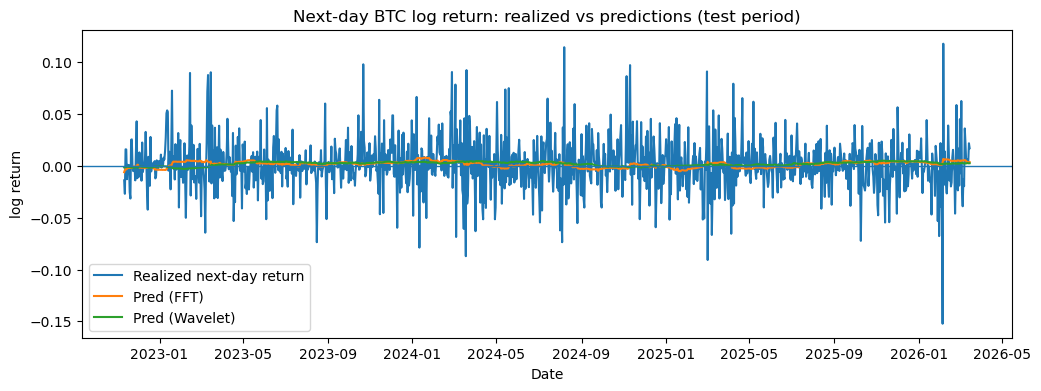

In [ ]:
# Plot predictions vs realized returns (regression)
plt.figure(figsize=(12,4))
plt.plot(idx_test, yreg_test, label="Realized next-day return")
plt.plot(idx_test, pred_fft, label="Pred (FFT)")
plt.plot(idx_test, pred_wav, label="Pred (Wavelet)")
plt.title("Next-day BTC log return: realized vs predictions (test period)")
plt.xlabel("Date"); plt.ylabel("log return")
plt.axhline(0, linewidth=1)
plt.legend()
plt.show()


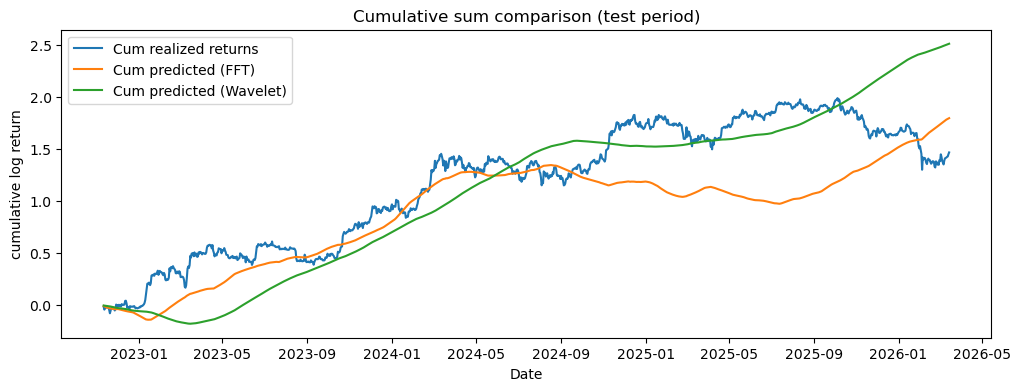

In [ ]:
# Cumulative sum of predicted returns (toy 'signal') vs realized (not a trading strategy)
cum_real = np.cumsum(yreg_test)
cum_fft = np.cumsum(pred_fft)
cum_wav = np.cumsum(pred_wav)

plt.figure(figsize=(12,4))
plt.plot(idx_test, cum_real, label="Cum realized returns")
plt.plot(idx_test, cum_fft, label="Cum predicted (FFT)")
plt.plot(idx_test, cum_wav, label="Cum predicted (Wavelet)")
plt.title("Cumulative sum comparison (test period)")
plt.xlabel("Date"); plt.ylabel("cumulative log return")
plt.legend()
plt.show()


<h2>6) Comparing the algorithms</h2>

What matters is **out-of-sample performance** relative to baselines.

Typical outcomes you may observe:

- **R² near 0** (or negative): indicates little linear predictability in daily returns with these features/models.
- Slight improvements in **MAE/RMSE** can happen, but may be economically insignificant.
- Directional **Accuracy** often hovers near ~50% for daily BTC data.

**FFT vs Wavelets** (conceptually):

- FFT assumes the signal is stationary within the window and summarizes *global* frequency content.  
- Wavelets summarize frequency content *localized in time*—helpful for transients/regime shifts.

If Wavelets outperform FFT in our run, it suggests that **time-localized structure** (volatility bursts, regime shifts) is more informative than global periodic components.


<h2>7) Conclusion: Is the next BTC “cycle” predictable from daily changes?</h2>

Based on these experiments (simple models + strict time split):

- If both methods are close to baseline, then **daily BTC returns are effectively hard to predict** with these frequency/scale features alone.
- If one method shows a small edge, treat it carefully:  
  it may be **data-mined**, unstable across periods, or dependent on parameter choices (window size, scales, regularization).

**What this implies about “market cycles”**  
FFT and Wavelets on daily returns can sometimes detect *dominant frequencies* or *multi-scale volatility patterns*, but turning that into reliable next-cycle forecasts is difficult. Cycles in crypto can be influenced by exogenous events (macro liquidity, regulation, halving narratives, risk-on/off) that are not captured in a short return window.


### Limitations

Despite the promising approach, several limitations must be acknowledged:

- Financial markets are highly noisy and influenced by external factors not captured in price data alone
- The models used are relatively simple and may not capture complex nonlinear relationships
- The evaluation is limited to a specific time period and may not generalize across different market regimes
- Feature engineering relies only on price-based signals, ignoring volume, sentiment, and macroeconomic variables


<h3>References (URLs)</h3>

- yfinance docs: https://github.com/ranaroussi/yfinance  
- SciPy FFT docs: https://docs.scipy.org/doc/scipy/reference/fft.html  
- SciPy CWT docs: https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.cwt.html  
- Morlet wavelet (SciPy): https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.morlet2.html  
- Intro to Fourier transform: https://en.wikipedia.org/wiki/Fourier_transform  
- Intro to wavelet transform: https://en.wikipedia.org/wiki/Wavelet_transform  
- Efficient Market Hypothesis (context for predictability): https://en.wikipedia.org/wiki/Efficient-market_hypothesis  
